In [6]:
####################################
#ENVIRONMENT SETUP

In [7]:
#LIBRARIES

#system
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import sys

#math and array operations
import numpy as np
import math

#plotting
import matplotlib
# matplotlib.use("Agg") #UNCOMMENT IF PLOTTING WITHIN JUPYTER DOCUMENT
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

#data classes
import xarray as xr
import h5py
import pickle 

#loading bar
from tqdm import tqdm

#dates
from datetime import datetime

In [8]:
#Importing DirectoryManager Class
sys.path.append(os.path.join("/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/","DataAnalysis","MPAS_Model_Data"))
from CLASSES_Directories import DirectoryManager_Class

In [9]:
DirectoryManager = DirectoryManager_Class()

codeType = os.path.join("DataAnalysis", "MPAS_Model_Data", "VariableComparisons")
dataType = "AreaAverages"

outputDirectory = DirectoryManager.GetOutputDirectory(codeType, dataType)
outputPlottingDirectory = DirectoryManager.GetOutputPlottingDirectory(codeType, dataType)

 DirectoryManager_Class Summary
 Main Directory:           /glade/u/home/aroseman/Projects/Regional-MPAS-Project
 Main Scratch Directory:   /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project
 Scratch Directory:        /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0
 Data Directory:           /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA
 Main Output Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT
 Main Output Plotting Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING
 Main Code Directory:      /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles
 Current Code Directory:   /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/MPAS_Model_Data/VariableComparisons



In [10]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_ModelData import StructuredModelData_Class, DataOperator_Class

In [11]:
def GetSimulationTime(RunType):
    if (RunType[0] == "TRACER") and (RunType[1] == "MOIST"):
        SimulationTime = ("2022-06-30","2022-07-03")
    return SimulationTime

# RunType = ("TRACER","MOIST","NSSL")
RunType = ("TRACER","MOIST","TEMPO")
SimulationTime = GetSimulationTime(RunType)
ModelData = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType, SimulationTime)

Found 289/289 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_TEMPO/history_cartesian/history.2022-06-30_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_TEMPO/diag_cartesian/diag.2022-06-30_00.00.00.latlon.nc

=== MPAS Structured (lat-lon) Model Data Summary ===
 Region:         TRACER
 Case:           MOIST
 Microphysics:   TEMPO
 Resolution:     20-1km
 Time Step:      15mins
 Time Range:     2022-06-30 to 2022-07-03
 Coordinates:    ['latitude', 'longitude', 'nVertLevels', 'nVertLevelsP1']
 # History Files:289
 # Diag Files:   289
 # Time Steps:   289
 Data Directory: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_TEMPO
 Static File:    TRACER_regional5250_scaled3_x20.835586.static.latlon.nc



In [14]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_DataSaving import DataSaving_Class

In [15]:
#Importing PlottingModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_PlottingModelData import RadarPlotting_Class

In [117]:
####################################
#CALCULATION FUNCTIONS

In [118]:
def InitiateMatrix(variableSubset):
    #3d variable case
    if ("nVertLevels" in variableSubset.dims):
        output = np.zeros((ModelData.Ntime,ModelData.Nzc))
    #3d variable case
    elif ("nVertLevelsP1" in variableSubset.dims):
        output = np.zeros((ModelData.Ntime,ModelData.Nzf))
    else:  #2d variable case
        output = np.zeros((ModelData.Ntime,1))
    return output

def GetMean(variableSubset):
    variableMean = variableSubset.mean(dim=("latitude","longitude"), skipna=True).data
    return variableMean

In [119]:
def GetVariableSubset_Helper(ModelData, dataSubset, dataSubset_diag, dataSubset_static, varName):
    """
    Retrieves a variable subset from the given model data.
    If varName contains a '+', returns the sum of the two variables.
    """
    if '+' in varName:
        var1, var2 = varName.split('+')
        var1 = var1.strip()
        var2 = var2.strip()

        subset1 = DataOperator_Class.GetData_Variable(ModelData, dataSubset, 
                                                      dataSubset_diag, dataSubset_static, var1)
        subset2 = DataOperator_Class.GetData_Variable(ModelData, dataSubset, 
                                                      dataSubset_diag, dataSubset_static, var2)
        variableSubset = subset1 + subset2
    else:
        variableSubset = DataOperator_Class.GetData_Variable(ModelData, dataSubset, 
                                                             dataSubset_diag, dataSubset_static, varName)

    return variableSubset

def RunCalculations(varNames):
    outputDictionary={}
    
    num_times = ModelData.Ntime
    for count, t in enumerate(tqdm(range(num_times), desc="Processing timesteps")):
        # if t % 10 == 0: print(f"Currently working on time {t}/{num_times}","\n")
            
        #Loading Data
        [dataSubset, dataSubset_diag, dataSubset_static, lat, lon, _, _] = DataOperator_Class.GetData_Subset(ModelData, t)

        for varName in varNames:
            if count == 0: print(f"Running for {varName}")
            #Subsetting Data

            variableSubset= GetVariableSubset_Helper(ModelData, dataSubset, dataSubset_diag, dataSubset_static, varName)

            if varName in ['refl10cm','refl10cm_1km']:
                variableSubset = variableSubset.where(variableSubset > 0)
            
            #Initializing Output
            if count == 0:
                output = InitiateMatrix(variableSubset)
                outputDictionary[varName] = output

            #Taking Mean
            if varName in ['refl10cm','refl10cm_1km']:
                # Convert from dBZ → linear Z (mm^6 m^-3)
                variableSubset_power = 10 ** (variableSubset / 10.0)
            
                # Take mean in linear space
                variableMean = GetMean(variableSubset_power)
            
                # Convert mean Z → back to dBZ
                variableMean = 10.0 * np.log10(variableMean)
                
            else:
                variableMean = GetMean(variableSubset)
                
            outputDictionary[varName][t] = variableMean

    return outputDictionary

# Notes:
# (1) may need to subset land/water later

In [120]:
####################################
#CALCULATION FUNCTIONS

In [121]:
def RunAreaAverages(varNames,name):
    #loading back in 
    try:
        filePath = DataOperator_Class.GetOutputFilePath(ModelData, DirectoryManager, outputDirectory, fileName = f"outputDictionary_{name}.h5")
        outputDictionary = DataSaving_Class.LoadDictionaryFromH5(filePath)
        return outputDictionary
    except Exception as e:
        print(f"Error: {e}")
        
        print("Running Calculation")
        outputDictionary = RunCalculations(varNames) #takes about 10 minutes
        #saving output
        filePath = DataOperator_Class.GetOutputFilePath(ModelData, DirectoryManager, outputDirectory, fileName = f"outputDictionary_{name}.h5")
        DataSaving_Class.SaveDictionaryToH5(outputDictionary, filePath)
        return outputDictionary

In [122]:
####################################
#CALCULATING

In [57]:
#running
def GetDictionary_1():
    #2D Variables (12 vars)
    #surface variables
    varNames = ["u10", "v10", "q2", "t2m", "th2m",
                "hfx", "qfx", "lh"]
    #microphysics variables
    varNames += ["refl10cm_1km","rainnc+rainc"]
    #convection variables
    varNames += ["cape", "cin"]
    outputDictionary_1 = RunAreaAverages(varNames, "1")
    return outputDictionary_1

outputDictionary_2D = GetDictionary_1()

Loaded 12 variables from /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/MPAS_Model_Data/VariableComparisons/AreaAverages/TRACER_MOIST_NSSL/outputDictionary_1.h5


In [58]:
#running
def GetDictionary_2():
    #3D Variables (9 vars)
    #microphysics variables
    varNames = ["refl10cm","qv", "qc+qi", "qr", "qg", "relhum"]
    #convection variables
    varNames += ["w", "theta", "divergence"]
    
    outputDictionary_2 = RunAreaAverages(varNames, "2")
    return outputDictionary_2

outputDictionary_3D = GetDictionary_2()

Loaded 9 variables from /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/MPAS_Model_Data/VariableComparisons/AreaAverages/TRACER_MOIST_NSSL/outputDictionary_2.h5


In [47]:
####################################
#PLOTTING FUNCTIONS

In [48]:
def GetVerticalCoord(dataSubset):
    pressure_profile = dataSubset['pressure'].mean(dim=("latitude","longitude")).data
    dp = pressure_profile[-1] - pressure_profile[-2]
    p_topface = pressure_profile[-1] + dp  # extrapolate linearly
    pressure_profile_face = np.append(pressure_profile, p_topface)
    return (pressure_profile/100,pressure_profile_face/100)

[dataSubset, dataSubset_diag, dataSubset_static, lat, lon, _, _] = DataOperator_Class.GetData_Subset(ModelData, t=0)
pressure_profiles = GetVerticalCoord(dataSubset)
time_strings = ModelData.timeStrings
time = [datetime.strptime(t, "%Y-%m-%d_%H.%M.%S") for t in time_strings]

In [49]:
def nansubtract(a, b):
    """
    Element-wise subtraction (a - b) that preserves NaNs.

    If shapes differ, raises a ValueError.
    """
    if a.shape != b.shape:
        raise ValueError(f"Shape mismatch: a{a.shape} != b{b.shape}")

    return np.where(np.isnan(a) | np.isnan(b), np.nan, a - b)

In [76]:
def PlotSingle(axis, outputDictionarys, varName, time, pressure_profiles, labels, plottype="TZ"):
    """
    Plot one variable on a given Matplotlib axis.
    Supports either one or two dictionaries.
    """

    def lineplot(time, output, varName, units, color, label):
        axis.plot(time, output.squeeze(), color=color, label=label)
        axis.set_ylabel(f"{varName} " + fr"$({units})$")
        axis.set_xlabel("Time")
        axis.grid(True)
        SetXLimitsDatetime(axis, time) #*#*

    # === Units and multiplier ===
    units = ModelData.GetUnits_Specific(varName).replace(" ", r"\ ")
    if varName in ["qv", "qc", "qi", "qr", "qg", "q2", "qfx"]:
        multiplier = 1e3
        units = units.replace('kg', 'g', 1)
    elif varName in ['divergence']:
        multiplier = -1
        units = units.replace('divergence', 'convergence')
    else:
        multiplier = 1

    # handle pressure profile
    sample_dict = outputDictionarys[0]
    output_sample = sample_dict[varName]
    pressure_profile = pressure_profiles[0] if output_sample.shape[1] == pressure_profiles[0].shape[0] else pressure_profiles[1]

    # --- CASE 1: ONE DICTIONARY ---
    if len(outputDictionarys) == 1:
        output = multiplier * outputDictionarys[0][varName]
        if varName in ["w","divergence"]:
            cmap = "RdBu_r"
            vmin, vmax = np.nanmin(output), np.nanmax(output)
            norm = TwoSlopeNorm(vcenter=0.0, vmin=vmin, vmax=vmax)
        else:
            cmap = "viridis"
            norm = None

        if output.ndim == 1 or output.shape[1] == 1:
            lineplot(time, output, varName, units, "k", None)
        else:
            if plottype == "TZ" and varName not in ['refl10cm','refl10cm_1km']:
                plot = axis.contourf(time, pressure_profile, output.T, cmap=cmap, norm=norm)
                plt.colorbar(plot, ax=axis, orientation="vertical", 
                             label=f"{varName} " + fr"$({units})$")
                axis.set_ylabel("Pressure (hPa)")
                axis.set_xlabel("Time")
                axis.invert_yaxis()
            elif plottype == "TZ" and varName in ['refl10cm','refl10cm_1km']:
                cmap, norm, levels, ticks = RadarPlotting_Class.GetReflectivityColormap()
                plot = axis.contourf(time, pressure_profile, output.T, 
                                    levels=levels, cmap=cmap, norm=norm, extend='both')
                cbar = axis.figure.colorbar(plot, ax=axis, orientation='vertical')
                RadarPlotting_Class.FormatReflectivityColorbar(cbar, ticks, orientation='vertical', show_labels=True)
                axis.set_ylabel("Pressure (hPa)")
                axis.set_xlabel("Time")
                axis.invert_yaxis()
            elif plottype == "T":
                output = np.nanmean(output, axis=1)
                lineplot(time, output, varName, units, "k", None)
    
    # --- CASE 2: TWO DICTIONARIES ---
    else:
        output1 = multiplier * outputDictionarys[0][varName]
        output2 = multiplier * outputDictionarys[1][varName]
        label1, label2 = labels
    
        # Determine if variable should be plotted as a line (1D or one vertical level)
        is_line = (
            output1.ndim == 1 and output2.ndim == 1 or
            output1.shape[1] == 1 and output2.shape[1] == 1
        )
    
        # --- CASE 2a: LINE VARIABLES ---
        if is_line:
            with np.errstate(invalid='ignore'):
                output1_mean = np.nanmean(output1, axis=1) if output1.ndim > 1 else output1
                output2_mean = np.nanmean(output2, axis=1) if output2.ndim > 1 else output2
            lineplot(time, output1_mean, varName, units, "blue", label1)
            lineplot(time, output2_mean, varName, units, "green", label2)
            axis.legend(loc='upper left')
    
        # --- CASE 2b: CONTOUR VARIABLES ---
        else:
            if plottype == "TZ":
                diff = nansubtract(output1,output2)
                cmap = "RdBu_r"
                vlim = np.nanmax(np.abs(diff))
                norm = TwoSlopeNorm(vcenter=0.0, vmin=-vlim, vmax=vlim)
                plot = axis.contourf(time, pressure_profile, diff.T, cmap=cmap, norm=norm)
                plt.colorbar(plot, ax=axis, orientation="vertical",
                             label=f"Δ{varName} " + fr"$({units})$")
                axis.set_ylabel("Pressure (hPa)")
                axis.set_xlabel("Time")
                axis.invert_yaxis()
    
            elif plottype == "T":
                # Average over pressure and plot line difference
                with np.errstate(invalid='ignore'):
                    output1_mean = np.nanmean(output1, axis=1)
                    output2_mean = np.nanmean(output2, axis=1)
                # diff = output1_mean - output2_mean
                # axis.plot(time, diff, color="black")
                # axis.set_ylabel(f"Δ{varName} " + fr"$({units})$")
                # axis.set_xlabel("Time")
                # axis.grid(True)
                lineplot(time, output1_mean, varName, units, "blue", label1)
                lineplot(time, output2_mean, varName, units, "green", label2)
                axis.legend(loc='upper left')

    if varName in ['divergence']:
        axis.set_title('convergence')
    else:
        axis.set_title(varName)
    # plt.gcf().autofmt_xdate()

def AlignAxesRight(ax_list):
    """
    Aligns the right edges of all axes in ax_list (e.g., contour + line plots),
    so that colorbars don't make some axes narrower.

    It uses the first axis that contains a contour or image
    (typically a contourf plot) as the reference width.
    """

    # Try to find a contour axis (has .collections or .images)
    ref_ax = None
    for ax in ax_list:
        if getattr(ax, "collections", []) or getattr(ax, "images", []):
            ref_ax = ax
            break

    # If no contour axis found, just use the first axis
    if ref_ax is None:
        ref_ax = ax_list[0]

    ref_pos = ref_ax.get_position()

    # Apply its width to all other axes
    for ax in ax_list:
        pos = ax.get_position()
        new_pos = [pos.x0, pos.y0, ref_pos.width, pos.height]
        ax.set_position(new_pos)

    print(f"Aligned {len(ax_list)} axes using reference width from contour axis at {ref_pos.width:.3f}")
# #EXAMPLE USAGE
# fig, axs = plt.subplots(2, 1, figsize=(8, 6))

# # contourf on top, line on bottom
# time = np.arange(24)
# pressure = np.linspace(1000, 100, 25)
# data = np.sin(time / 3)[None, :] * np.exp(-pressure[:, None] / 1000)

# plot = axs[0].contourf(time, pressure, data, cmap="RdBu_r")
# plt.colorbar(plot, ax=axs[0], orientation="vertical", pad=0.02)
# axs[1].plot(time, np.sin(time / 3), color="k")

# # Align both
# AlignAxesRight(axs)

# plt.show()

# Example: align datetime x-limits to min/max of your data
def SetXLimitsDatetime(ax, time_array):
    """
    Ensures datetime x-axis starts and ends exactly at the first and last time values.
    Works for both datetime.datetime and np.datetime64 arrays.
    """
    import numpy as np
    from matplotlib.dates import date2num

    # Convert to Matplotlib’s internal float format if needed
    times = np.asarray(time_array)
    if np.issubdtype(times.dtype, np.datetime64):
        times = date2num(times)
    elif isinstance(times[0], (object,)):
        try:
            times = date2num(times)
        except Exception:
            pass

    ax.set_xlim(times.min(), times.max())

In [51]:
####################################
#PLOTTING

In [59]:
#getting NSSL dictionaries
RunType = ("TRACER","MOIST","NSSL")
SimulationTime = GetSimulationTime(RunType)
ModelData = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType, SimulationTime)

outputDictionary_2D_NSSL = GetDictionary_1()
outputDictionary_3D_NSSL = GetDictionary_2()

#getting TEMPO dictionaries
RunType = ("TRACER","MOIST","TEMPO")
SimulationTime = GetSimulationTime(RunType)
ModelData = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType, SimulationTime)

outputDictionary_2D_TEMPO = GetDictionary_1()
outputDictionary_3D_TEMPO = GetDictionary_2()

#extrapolating th2m for time 0 
for a in [outputDictionary_2D_NSSL,outputDictionary_2D_TEMPO]:
    a['th2m'][0] = 2 * a['th2m'][1] - a['th2m'][2]

Found 289/289 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_NSSL/history_cartesian/history.2022-06-30_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_NSSL/diag_cartesian/diag.2022-06-30_00.00.00.latlon.nc

=== MPAS Structured (lat-lon) Model Data Summary ===
 Region:         TRACER
 Case:           MOIST
 Microphysics:   NSSL
 Resolution:     20-1km
 Time Step:      15mins
 Time Range:     2022-06-30 to 2022-07-03
 Coordinates:    ['latitude', 'longitude', 'nVertLevels', 'nVertLevelsP1']
 # History Files:289
 # Diag Files:   289
 # Time Steps:   289
 Data Directory: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_NSSL
 Static File:    TRACER_regional5250_scaled3_x20.835586.static.latlon.nc

Loaded 12 variables from /

In [74]:
# setting up dictionaries for plotting
labels = ("NSSL", "TEMPO")

# variable groups
varGroups = {
    "T_1": outputDictionary_2D_NSSL.keys(),
    "T_2": outputDictionary_3D_NSSL.keys(),
    "TZ_1": ["refl10cm", "qv", "qc+qi", "qr", "qg", "relhum"],
    "TZ_2": ["w", "theta", "divergence"]
}

# model source dictionaries
modelDicts = {
    "NSSL": [outputDictionary_2D_NSSL, outputDictionary_3D_NSSL],
    "TEMPO": [outputDictionary_2D_TEMPO, outputDictionary_3D_TEMPO],
}

# --- function ---
def GetCombinedDictionary(varNames, dicts):
    """Get varName: value from the first dict in `dicts` that contains it."""
    return {v: next((d[v] for d in dicts if v in d), None) for v in varNames}

# --- build labeled combined structure ---
combinedDictionary = {
    group: {
        label: GetCombinedDictionary(varNames, modelDicts[label])
        for label in labels
    }
    for group, varNames in varGroups.items()
}

#Format of combinedDictionary
# Combined[key] = { "NSSL": {...}, "TEMPO": {...} }

In [108]:
def SaveFigure(fig, combinedDict, key,label_text ):
    """
    Saves a figure to the appropriate directory based on the models in combinedDict.
    """
    # --- Define output subdirectory and file path ---
    outputSubDirectory = f"{ModelData.region}_{ModelData.case}_{label_text}"
    os.makedirs(os.path.join(outputPlottingDirectory, outputSubDirectory), exist_ok=True)

    outputFile = os.path.join(
        outputPlottingDirectory,
        outputSubDirectory,
        f"CombinedPlot_{key}.png"
    )

    # # --- Save figure ---
    # fig.savefig(outputFile, dpi=100, bbox_inches="tight")
    # plt.close(fig)
    print(f"Saved to {outputFile}")


def MakeCombinedPlot(combinedDict, key, plottype):
    """
    Creates a combined plot from a model-comparison dictionary:
    combinedDict = {"NSSL": {...}, "TEMPO": {...}, ...}
    """
    # --- Automatically get model labels and first model's varNames ---
    combinedDict2 = combinedDict[key]
    modelLabels = list(combinedDict2.keys())
    first_model = modelLabels[0]
    varNames = combinedDict2[first_model].keys()

    # --- Normal layout logic ---
    n_vars = len(varNames)
    n_cols = 3
    n_rows = int(np.ceil(n_vars / n_cols))

    fig = plt.figure(figsize=(6 * n_cols, 3.5 * n_rows))
    gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, wspace=0.2, hspace=0.4)

    # --- Loop through variables ---
    for i, varName in enumerate(varNames):
        row, col = divmod(i, n_cols)
        ax = fig.add_subplot(gs[row, col])

        # Extract corresponding model data in correct label order
        modelDicts = [combinedDict2[label] for label in modelLabels]

        # Pass directly to PlotSingle (no need for manual labels)
        PlotSingle(ax, modelDicts, varName, time, pressure_profiles,
                   labels=modelLabels, plottype=plottype)

    # --- Format axes ---
    for ax in fig.get_axes():
        ax.tick_params(labelbottom=True)
        ax.set_xlabel("Time")
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    plt.subplots_adjust(left=0.07, right=0.97, bottom=0.07, top=0.93,
                        wspace=0.4, hspace=0.6)

    # Align all axes for clean layout
    AlignAxesRight(fig.get_axes())

    # --- Making Title ---
    label_text = " vs ".join(modelLabels)
    plt.suptitle(f"{ModelData.region}_{ModelData.case} {label_text}")

    # --- Saving Figure ---
    label_text = label_text.replace(" ","")
    SaveFigure(fig, combinedDict2, key, label_text)
    return fig

/glade/derecho/scratch/aroseman/tmp/ipykernel_34408/2029549282.py:80: RuntimeWarning: Mean of empty slice
  output2_mean = np.nanmean(output2, axis=1) if output2.ndim > 1 else output2


Aligned 12 axes using reference width from contour axis at 0.265
Saved to /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING/DataAnalysis/MPAS_Model_Data/VariableComparisons/AreaAverages/TRACER_MOIST_NSSLvsTEMPO/CombinedPlot_T_1.png


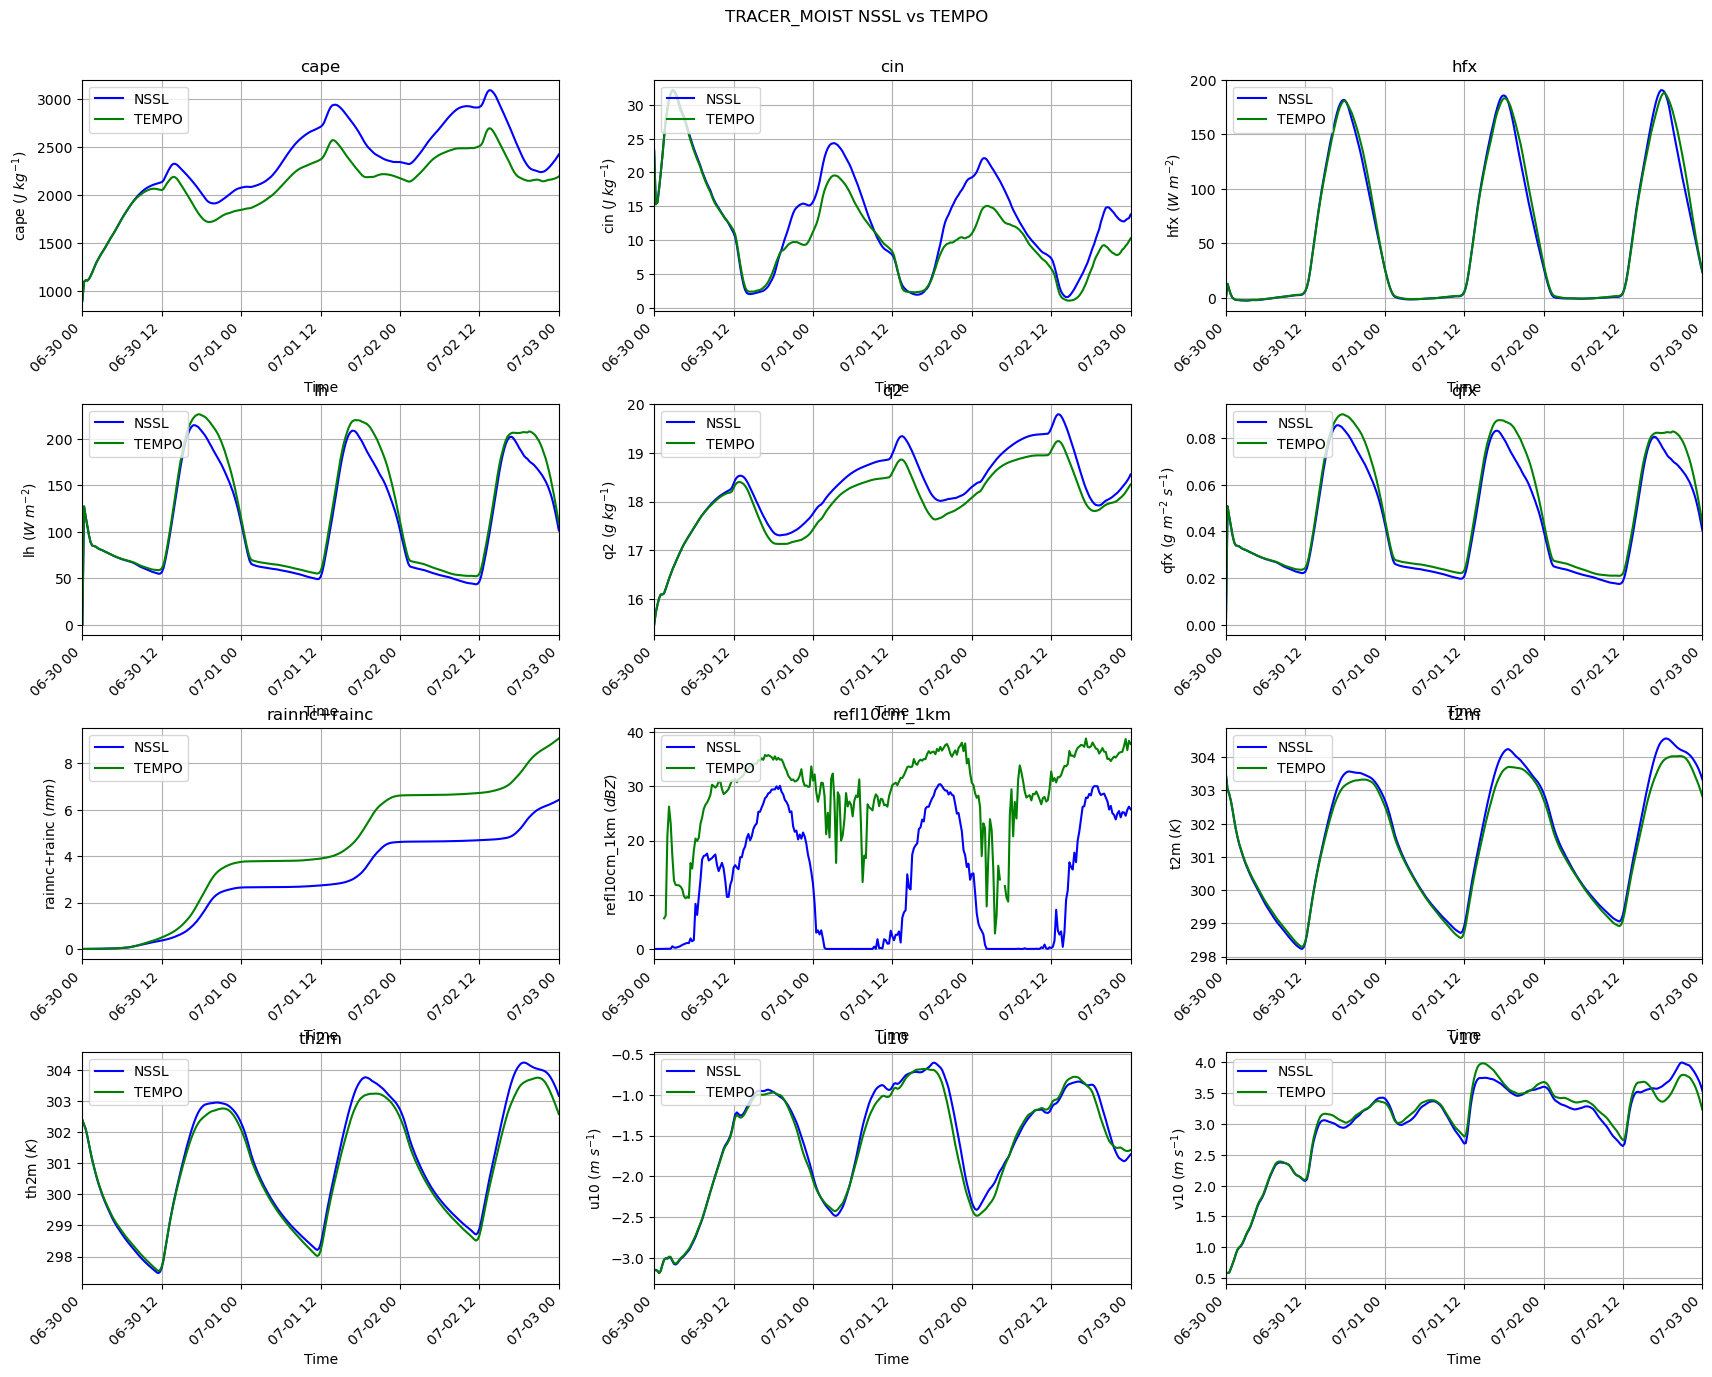

In [109]:
#2D Variable Plots
fig = MakeCombinedPlot(combinedDictionary, key = "T_1", plottype="T")
# fig = MakeCombinedPlot(combinedDictionary, key = "T_2", plottype="T")

Aligned 6 axes using reference width from contour axis at 0.212


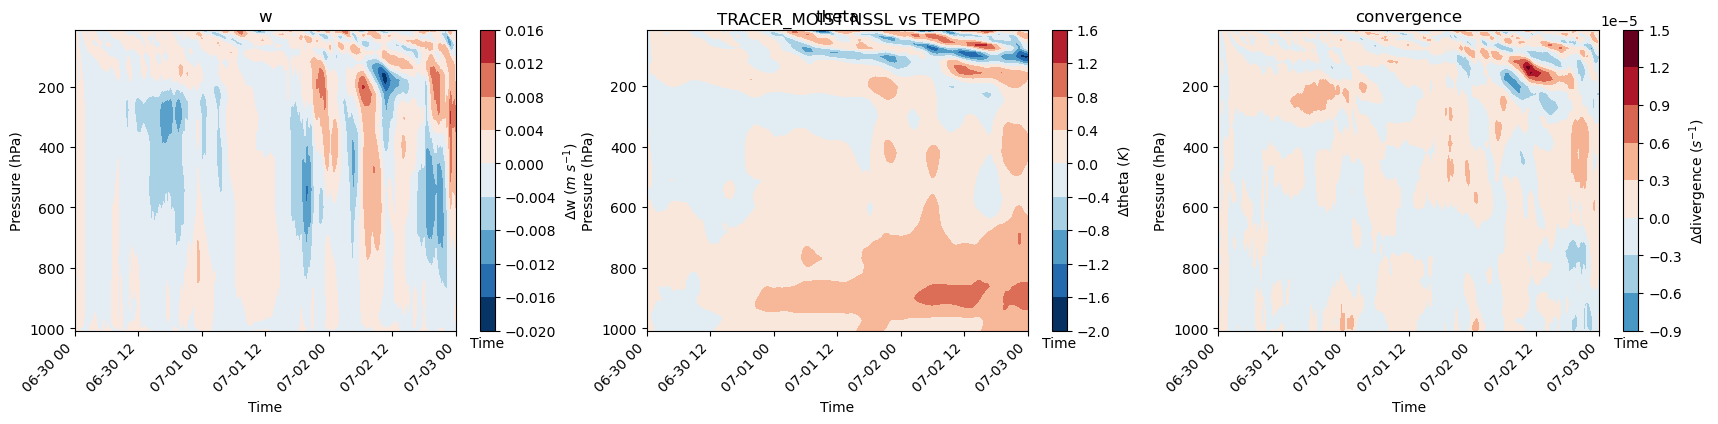

In [95]:
#3D Variable Plots
# fig = MakeCombinedPlot(combinedDictionary["TZ_1"], plottype="TZ")
fig = MakeCombinedPlot(combinedDictionary["TZ_2"], plottype="TZ")